In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns)
print("\nData types:")
print(df.dtypes)

Dataset shape: (7043, 21)

Column names:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn

In [5]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [6]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [7]:
print(df["Churn"].value_counts())
print("\nChurn percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [8]:
print("Contract types:")
print(df["Contract"].unique())

print("\nInternet service types:")
print(df["InternetService"].unique())

print("\nPayment methods:")
print(df["PaymentMethod"].unique())

Contract types:
['Month-to-month' 'One year' 'Two year']

Internet service types:
['DSL' 'Fiber optic' 'No']

Payment methods:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [9]:
print("TotalCharges data type:", df["TotalCharges"].dtype)

print("\nBlank TotalCharges values:")
print((df["TotalCharges"] == " ").sum())

TotalCharges data type: object

Blank TotalCharges values:
11


In [10]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("TotalCharges data type:", df["TotalCharges"].dtype)
print("Missing TotalCharges values:", df["TotalCharges"].isnull().sum())

TotalCharges data type: float64
Missing TotalCharges values: 11


In [11]:
df = df.dropna(subset=["TotalCharges"])

print("Dataset shape after cleaning:", df.shape)
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

Dataset shape after cleaning: (7032, 21)
Missing TotalCharges: 0


In [12]:
df = df.drop("customerID", axis=1)

print("Dataset shape:", df.shape)
print("\nRemaining columns:")
print(df.columns)

Dataset shape: (7032, 20)

Remaining columns:
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [13]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDataset shape:", df.shape)

Missing values:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows: 22

Dataset shape: (7032, 20)


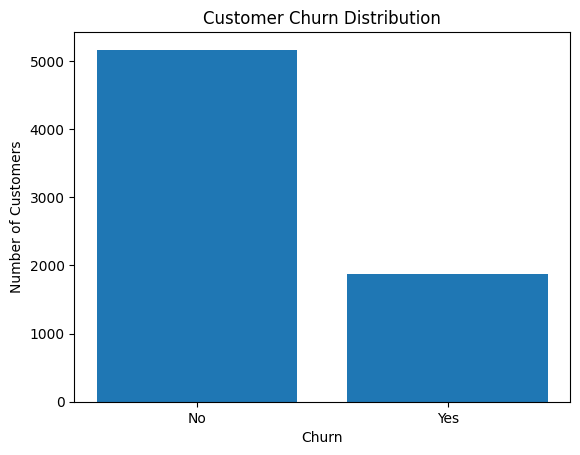

In [14]:
churn_counts = df["Churn"].value_counts()

plt.bar(churn_counts.index, churn_counts.values)

plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Distribution")

plt.show()

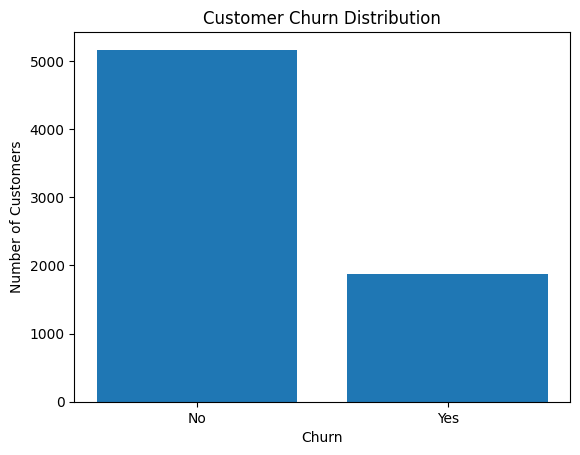

In [15]:
churn_counts = df["Churn"].value_counts()

plt.bar(churn_counts.index, churn_counts.values)

plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Distribution")

plt.show()

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665


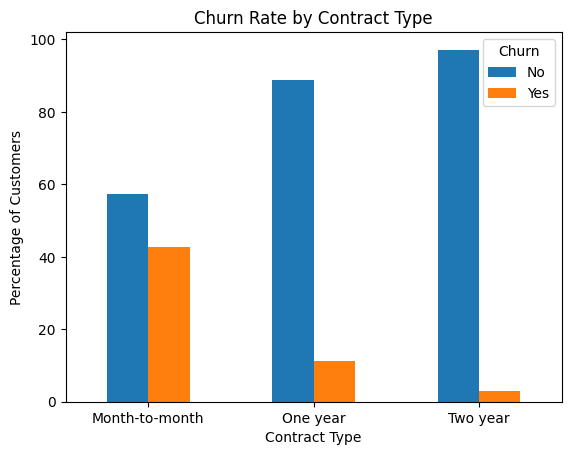

In [16]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

print(contract_churn)

contract_churn.plot(kind="bar")

plt.xlabel("Contract Type")
plt.ylabel("Percentage of Customers")
plt.title("Churn Rate by Contract Type")

plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

Churn            No        Yes
tenure                        
(0, 12]   52.321839  47.678161
(12, 24]  71.289062  28.710938
(24, 48]  79.611041  20.388959
(48, 72]  90.486824   9.513176


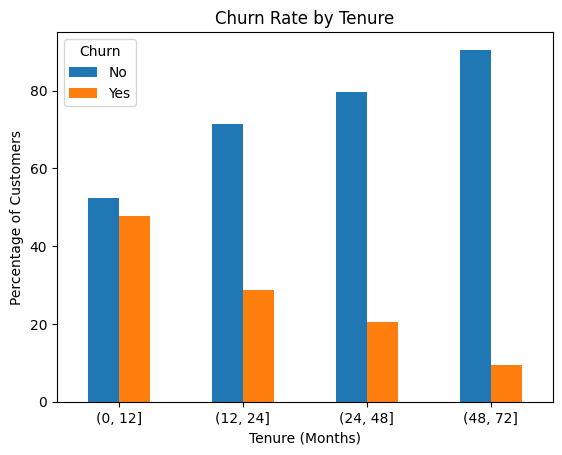

In [17]:
tenure_churn = pd.crosstab(
    pd.cut(df["tenure"], bins=[0, 12, 24, 48, 72]),
    df["Churn"],
    normalize="index"
) * 100

print(tenure_churn)

tenure_churn.plot(kind="bar")

plt.xlabel("Tenure (Months)")
plt.ylabel("Percentage of Customers")
plt.title("Churn Rate by Tenure")

plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64


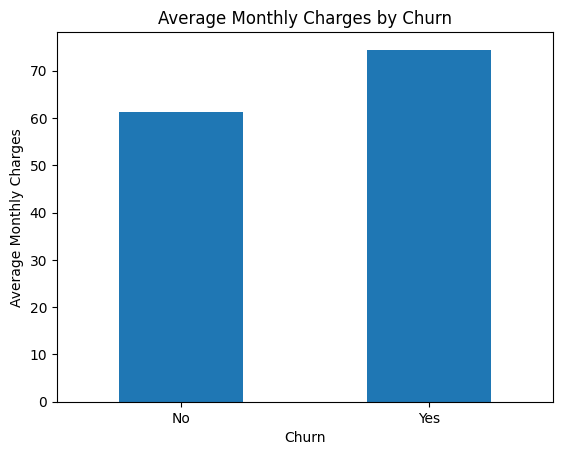

In [18]:
monthly_charges_churn = df.groupby("Churn")["MonthlyCharges"].mean()

print(monthly_charges_churn)

monthly_charges_churn.plot(kind="bar")

plt.xlabel("Churn")
plt.ylabel("Average Monthly Charges")
plt.title("Average Monthly Charges by Churn")

plt.xticks(rotation=0)

plt.show()

Churn                   No        Yes
InternetService                      
DSL              81.001656  18.998344
Fiber optic      58.107235  41.892765
No               92.565789   7.434211


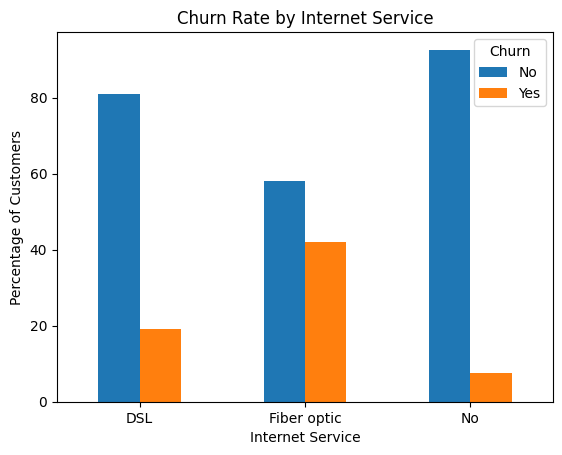

In [19]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print(internet_churn)

internet_churn.plot(kind="bar")

plt.xlabel("Internet Service")
plt.ylabel("Percentage of Customers")
plt.title("Churn Rate by Internet Service")

plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.268482  16.731518
Credit card (automatic)    84.746877  15.253123
Electronic check           54.714588  45.285412
Mailed check               80.798005  19.201995


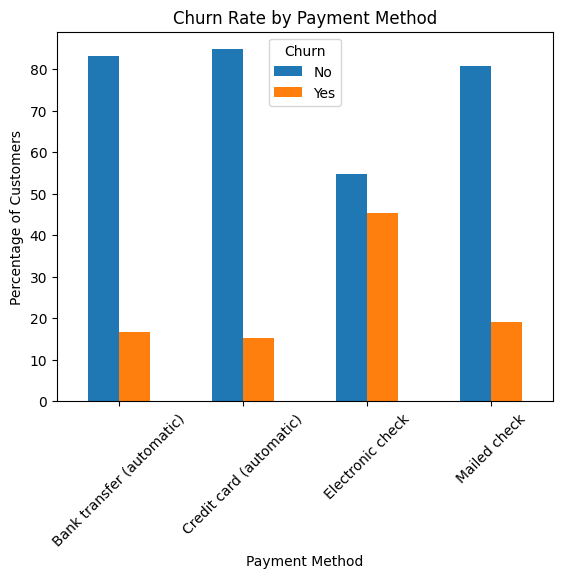

In [20]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print(payment_churn)

payment_churn.plot(kind="bar")

plt.xlabel("Payment Method")
plt.ylabel("Percentage of Customers")
plt.title("Churn Rate by Payment Method")

plt.xticks(rotation=45)
plt.legend(title="Churn")

plt.show()

Churn                       No        Yes
OnlineSecurity                           
No                   58.221333  41.778667
No internet service  92.565789   7.434211
Yes                  85.359801  14.640199


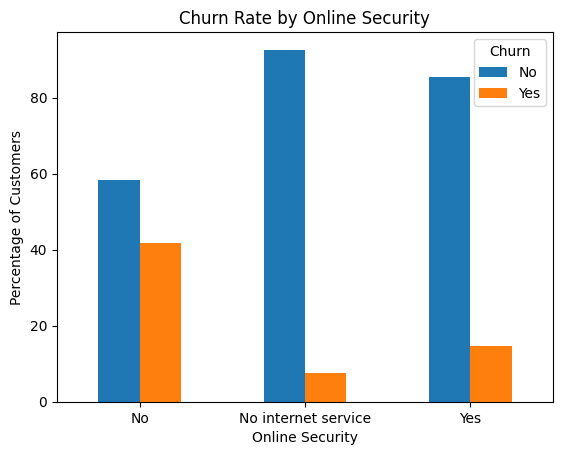

In [21]:
security_churn = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

print(security_churn)

security_churn.plot(kind="bar")

plt.xlabel("Online Security")
plt.ylabel("Percentage of Customers")
plt.title("Churn Rate by Online Security")

plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

Churn                       No        Yes
TechSupport                              
No                   58.352535  41.647465
No internet service  92.565789   7.434211
Yes                  84.803922  15.196078


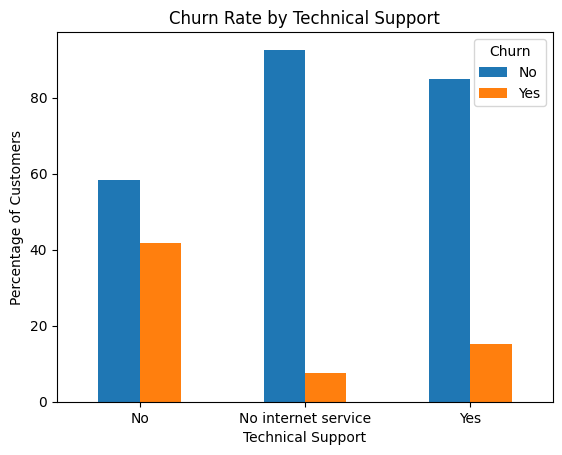

In [22]:
tech_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

print(tech_churn)

tech_churn.plot(kind="bar")

plt.xlabel("Technical Support")
plt.ylabel("Percentage of Customers")
plt.title("Churn Rate by Technical Support")

plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

Contract
Month-to-month    66.398490
One year          65.079416
Two year          60.872374
Name: MonthlyCharges, dtype: float64


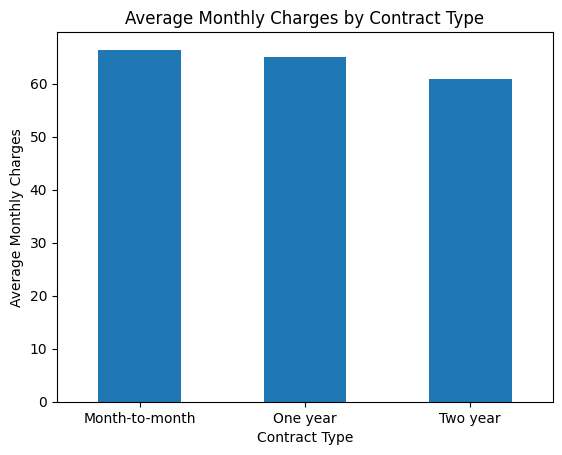

In [23]:
contract_charges = df.groupby("Contract")["MonthlyCharges"].mean()

print(contract_charges)

contract_charges.plot(kind="bar")

plt.xlabel("Contract Type")
plt.ylabel("Average Monthly Charges")
plt.title("Average Monthly Charges by Contract Type")

plt.xticks(rotation=0)

plt.show()

tenure
1     50.485808
2     57.206303
3     58.015000
4     57.432670
5     61.003759
        ...    
68    73.321000
69    70.823158
70    76.378992
71    73.735588
72    80.695856
Name: MonthlyCharges, Length: 72, dtype: float64


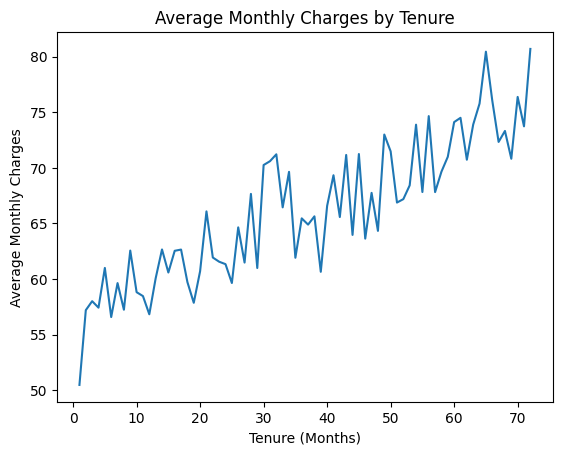

In [24]:
tenure_charges = df.groupby("tenure")["MonthlyCharges"].mean()

print(tenure_charges)

tenure_charges.plot(kind="line")

plt.xlabel("Tenure (Months)")
plt.ylabel("Average Monthly Charges")
plt.title("Average Monthly Charges by Tenure")

plt.show()

Churn                 No        Yes
SeniorCitizen                      
0              76.349745  23.650255
1              58.318739  41.681261


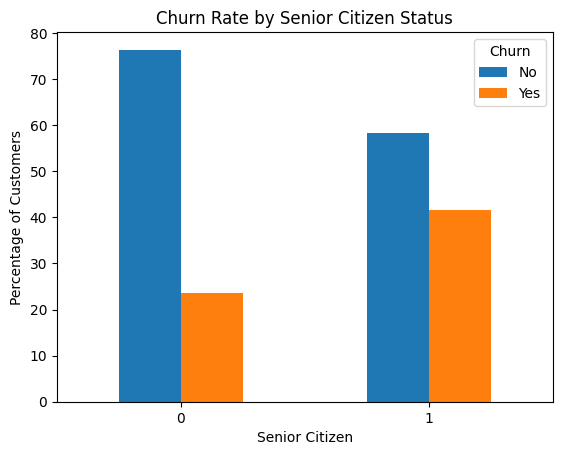

In [25]:
senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

print(senior_churn)

senior_churn.plot(kind="bar")

plt.xlabel("Senior Citizen")
plt.ylabel("Percentage of Customers")
plt.title("Churn Rate by Senior Citizen Status")

plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

In [26]:
print(df[["tenure", "MonthlyCharges", "TotalCharges"]].describe())

            tenure  MonthlyCharges  TotalCharges
count  7032.000000     7032.000000   7032.000000
mean     32.421786       64.798208   2283.300441
std      24.545260       30.085974   2266.771362
min       1.000000       18.250000     18.800000
25%       9.000000       35.587500    401.450000
50%      29.000000       70.350000   1397.475000
75%      55.000000       89.862500   3794.737500
max      72.000000      118.750000   8684.800000


In [27]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print(df["Churn"].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [28]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7032, 19)
y shape: (7032,)


In [29]:
X = pd.get_dummies(X, drop_first=True)

print("X shape after encoding:", X.shape)
print(X.head())

X shape after encoding: (7032, 30)
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85        False   
1              0      34           56.95       1889.50         True   
2              0       2           53.85        108.15         True   
3              0      45           42.30       1840.75         True   
4              0       2           70.70        151.65        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  MultipleLines_Yes  ...  \
0                            True              False  ...   
1                           False              False  ...   
2                           False         

In [30]:
X = X.astype(int)

print(X.head())

print("\nData types:")
print(X.dtypes)

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1              29            29            0   
1              0      34              56          1889            1   
2              0       2              53           108            1   
3              0      45              42          1840            1   
4              0       2              70           151            0   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0            1               0                 0   
1            0               0                 1   
2            0               0                 1   
3            0               0                 0   
4            0               0                 1   

   MultipleLines_No phone service  MultipleLines_Yes  ...  \
0                               1                  0  ...   
1                               0                  0  ...   
2                               0                  0  ...   
3               

In [31]:
X["MonthlyCharges"] = df["MonthlyCharges"]
X["TotalCharges"] = df["TotalCharges"]

print(X[["MonthlyCharges", "TotalCharges"]].head())

   MonthlyCharges  TotalCharges
0           29.85         29.85
1           56.95       1889.50
2           53.85        108.15
3           42.30       1840.75
4           70.70        151.65


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 30)
Testing data: (1407, 30)


In [33]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [34]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:20])

Predictions:
[0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 1 1 0 1 0]


In [35]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100)

Accuracy: 0.7874911158493249
Accuracy percentage: 78.74911158493248


In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [37]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[915 118]
 [181 193]]


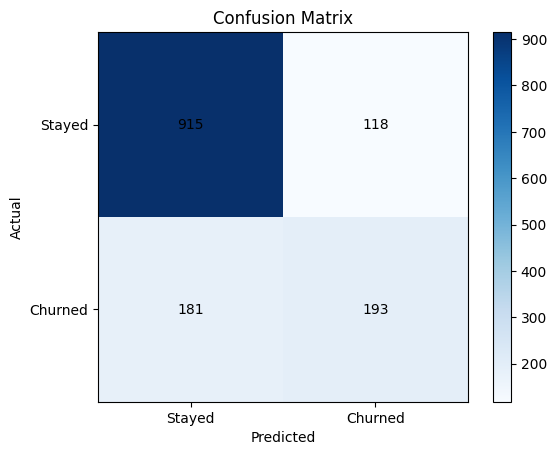

In [39]:
plt.imshow(cm, cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks([0, 1], ["Stayed", "Churned"])
plt.yticks([0, 1], ["Stayed", "Churned"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [40]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [41]:
rf_pred = rf_model.predict(X_test)

print("Random Forest predictions:")
print(rf_pred[:20])

Random Forest predictions:
[0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 0 0]


Random Forest Accuracy: 0.7853589196872779
Random Forest Accuracy Percentage: 78.53589196872778

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407

Confusion Matrix:
[[927 106]
 [196 178]]


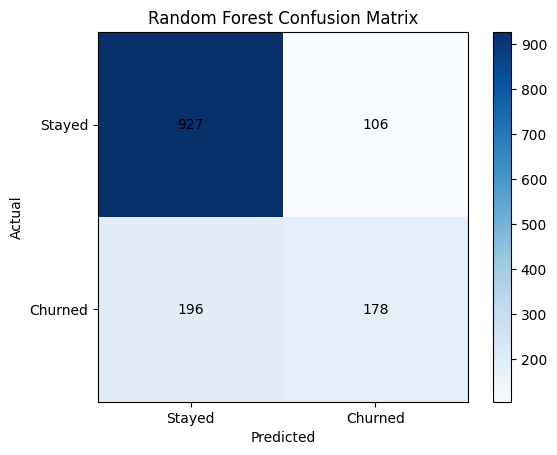

In [42]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Accuracy Percentage:", rf_accuracy * 100)

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

rf_cm = confusion_matrix(y_test, rf_pred)

print("Confusion Matrix:")
print(rf_cm)

plt.imshow(rf_cm, cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.colorbar()

plt.xticks([0, 1], ["Stayed", "Churned"])
plt.yticks([0, 1], ["Stayed", "Churned"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, rf_cm[i, j], ha="center", va="center")

plt.show()

In [43]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(10))

TotalCharges                      0.193409
MonthlyCharges                    0.169758
tenure                            0.167572
InternetService_Fiber optic       0.039999
PaymentMethod_Electronic check    0.035016
OnlineSecurity_Yes                0.028905
Contract_Two year                 0.028618
gender_Male                       0.026971
TechSupport_Yes                   0.025829
PaperlessBilling_Yes              0.025044
dtype: float64


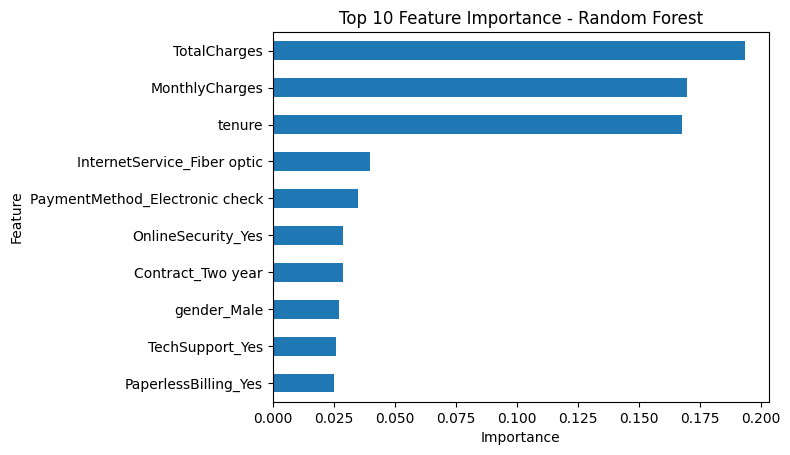

In [44]:
top_features = feature_importance.head(10)

top_features.plot(kind="barh")

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - Random Forest")

plt.gca().invert_yaxis()

plt.show()